In [14]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn import preprocessing
from sklearn.tree import export_text
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score


%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

## Time to get your hands dirty! Can a computer learn if we're going to detect gravitational waves?

[This dataset](https://github.com/dgerosa/pdetclassifier/releases/download/v0.2/sample_2e7_design_precessing_higherordermodes_3detectors.h5) contains simulated gravitational-wave signals from merging black holes (careful the file size is >1 GB). If you've never seen them, the [.h5 format](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) is a highly optimized storage strategy for large datasets. It's amazing. In python, you can read it with `h5py`.

In particular, each source has the following features:
- `mtot`: the total mass of the binary
- `q`: the mass ratio
- `chi1x`, `chi1y`, `chi1z`, `chi2x`, `chi2y`, `chi2z`: the components of the black-hole spins in a suitable reference frame.
- `ra`, `dec`: the location of the source in the sky
- `iota`: the inclination of the orbital plane'
- `psi`: the polarization angle (gravitational waves have two polarization states much like light)
- `z`: the redshift

The detectability is defined using the `snr` (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network. We threshold the `snr` values and assume that LIGO will (not) see a source if `snr`>12 (`snr`<12). The resulting 0-1 labels are reported in the `det` attribute in the dataset.

Today's task is to train a classifier (you decide which one!) and separate sources that are detectables from those that aren't. 

Be creative! This is a challenge! Let's see who gets the  higher completeness and/or the smaller contamination (on a validation set, of course, careful with overfitting here).

*Tips*:
- You can downsample the data for debugging purposes
- You can also use only some of the features.
- Plot ROC curves
- **Important** Don't use `snr` as a feature in your classifer (that's the answer...)


In [15]:
data = h5py.File('gw.h5')

In [16]:
data.keys()

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>

In [17]:
keys = ['chi1x', 'chi1y','chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra', 'z' ]
X = np.column_stack([data[k][:10000] for k in keys])
y = data['det'][:10000]

In [18]:
print(np.sum(y))

1462


In [19]:
scaler = preprocessing.StandardScaler() # working column-wise
scaler.fit(X)
X = scaler.transform(X)

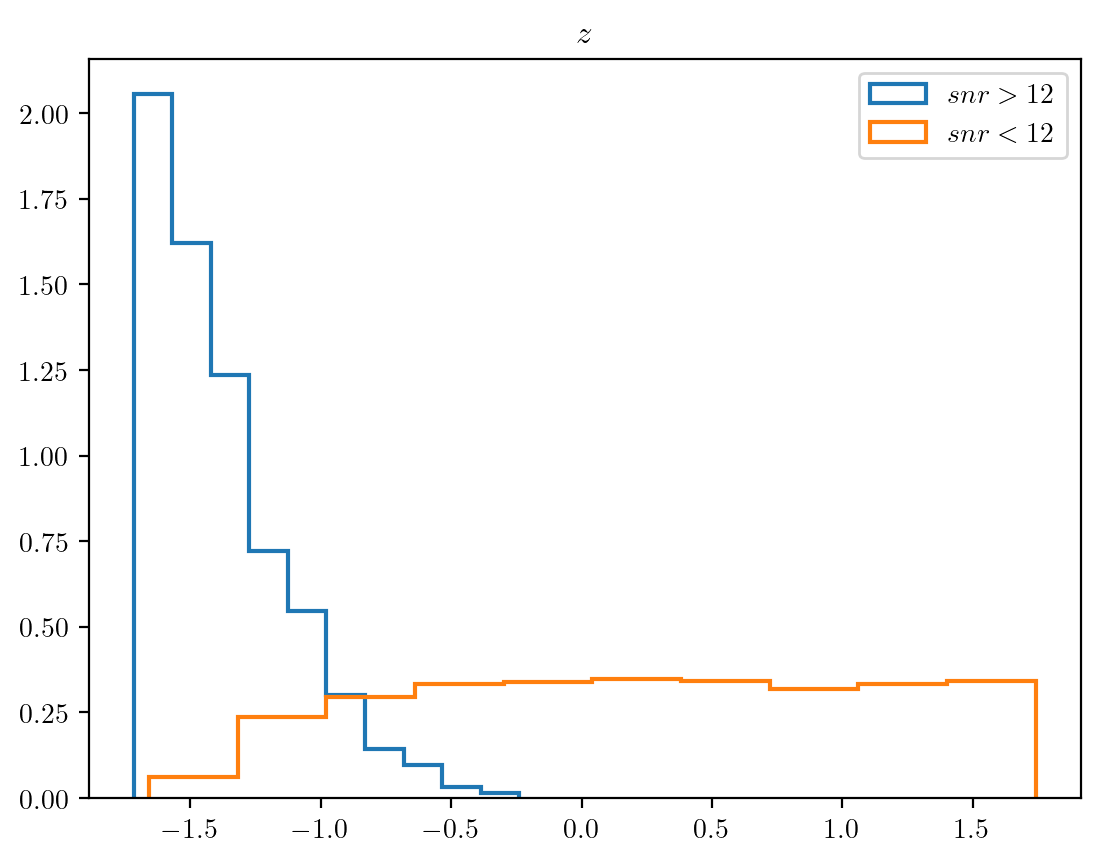

In [20]:
_ = plt.hist((X[:,12])[y == 1], histtype='step', density=True, label = '$snr > 12$', lw = 1.5)
_ = plt.hist((X[:,12])[y == 0], histtype='step', density=True, label = '$snr < 12$', lw = 1.5)
plt.title('$z$')
plt.legend()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
def kfold_cv(Xtrain, ytrain, model):

    kf = KFold(n_splits=5, shuffle=True)

    eps_cv = []
    eps_tr = []

    for train, val in kf.split(Xtrain):

        Xval = Xtrain[val]
        yval = ytrain[val]

        Xtr = Xtrain[train]
        ytr = ytrain[train]

        model.fit(Xtr, ytr)
        yprob_tr = model.predict_proba(Xtr)[:,1]
        yprob_val = model.predict_proba(Xval)[:,1]
        ypred_tr = model.predict(Xtr)
        ypred_val = model.predict(Xval)

        CM_tr = (confusion_matrix(ytr, ypred_tr))
        CM_val = (confusion_matrix(yval, ypred_val))

        tn_tr, fp_tr, fn_tr, tp_tr = CM_tr.ravel()
        completeness_tr = (tp_tr/(tp_tr+fn_tr))

        tn, fp, fn, tp = CM_val.ravel()
        completeness = (tp/(tp+fn))

        eps_tr.append(completeness_tr)
        eps_cv.append(completeness)

    return np.mean(eps_tr), np.mean(eps_cv)

6


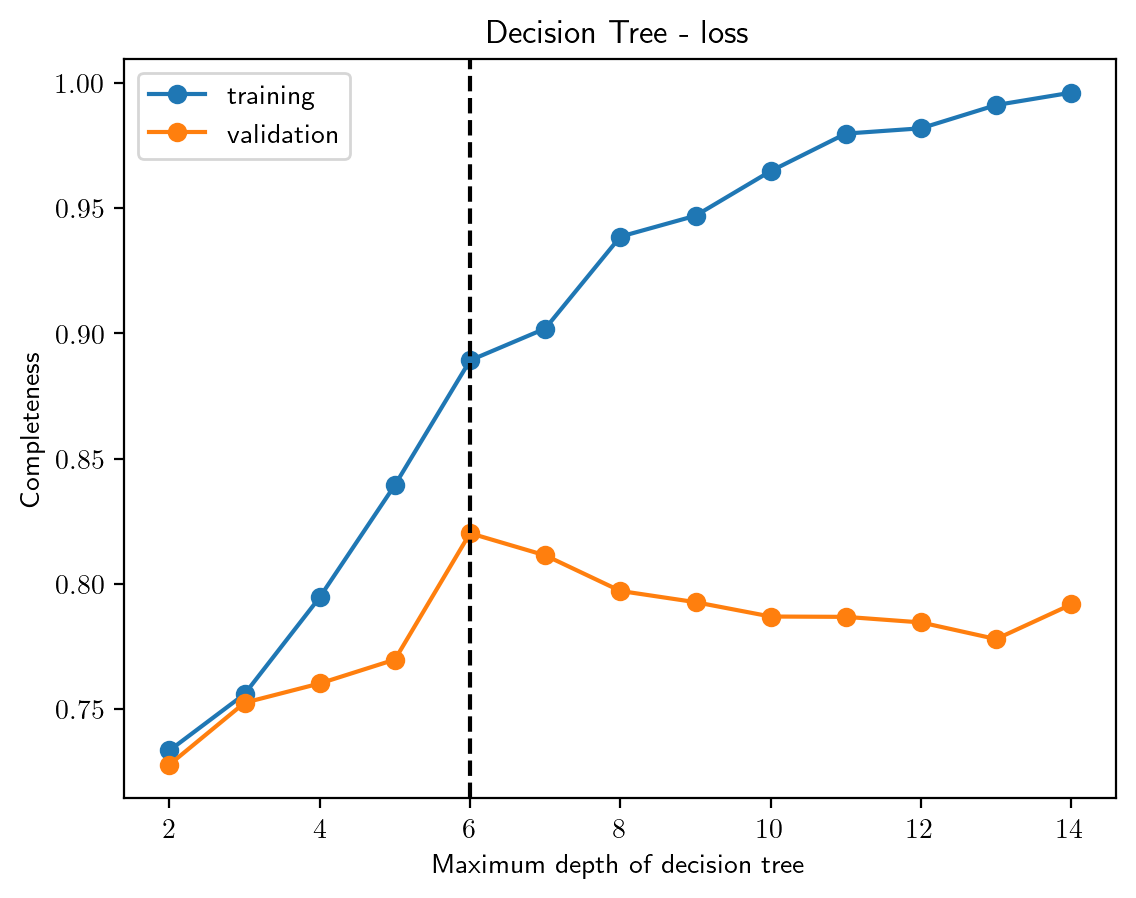

In [23]:
depths = np.arange(2,15)
tr_loss = np.zeros(len(depths))
cv_loss = np.zeros(len(depths))
for i,d in enumerate(depths):
        tr_loss[i], cv_loss[i] = kfold_cv(X_train, y_train, model = DTC(max_depth=d)) 

plt.plot(depths, tr_loss, label = 'training', marker = 'o')
plt.plot(depths, cv_loss, label = 'validation', marker = 'o')
plt.xlabel('Maximum depth of decision tree')
plt.ylabel('Completeness')
plt.legend()
plt.axvline(depths[np.argmax(cv_loss)], c = 'black', ls = '--')
plt.title('Decision Tree - loss')

best_depth = depths[np.argmax(cv_loss)]
print(best_depth)

|--- z <= -1.23
|   |--- z <= -1.39
|   |   |--- mtot <= -1.66
|   |   |   |--- z <= -1.60
|   |   |   |   |--- mtot <= -1.72
|   |   |   |   |   |--- ra <= -0.78
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- ra >  -0.78
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- mtot >  -1.72
|   |   |   |   |   |--- class: 1
|   |   |   |--- z >  -1.60
|   |   |   |   |--- class: 0
|   |   |--- mtot >  -1.66
|   |   |   |--- z <= -1.47
|   |   |   |   |--- z <= -1.49
|   |   |   |   |   |--- chi2x <= -2.21
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- chi2x >  -2.21
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- z >  -1.49
|   |   |   |   |   |--- z <= -1.49
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- z >  -1.49
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- z >  -1.47
|   |   |   |   |--- mtot <= -1.20
|   |   |   |   |   |--- chi2x <= -0.18
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- chi2x > 

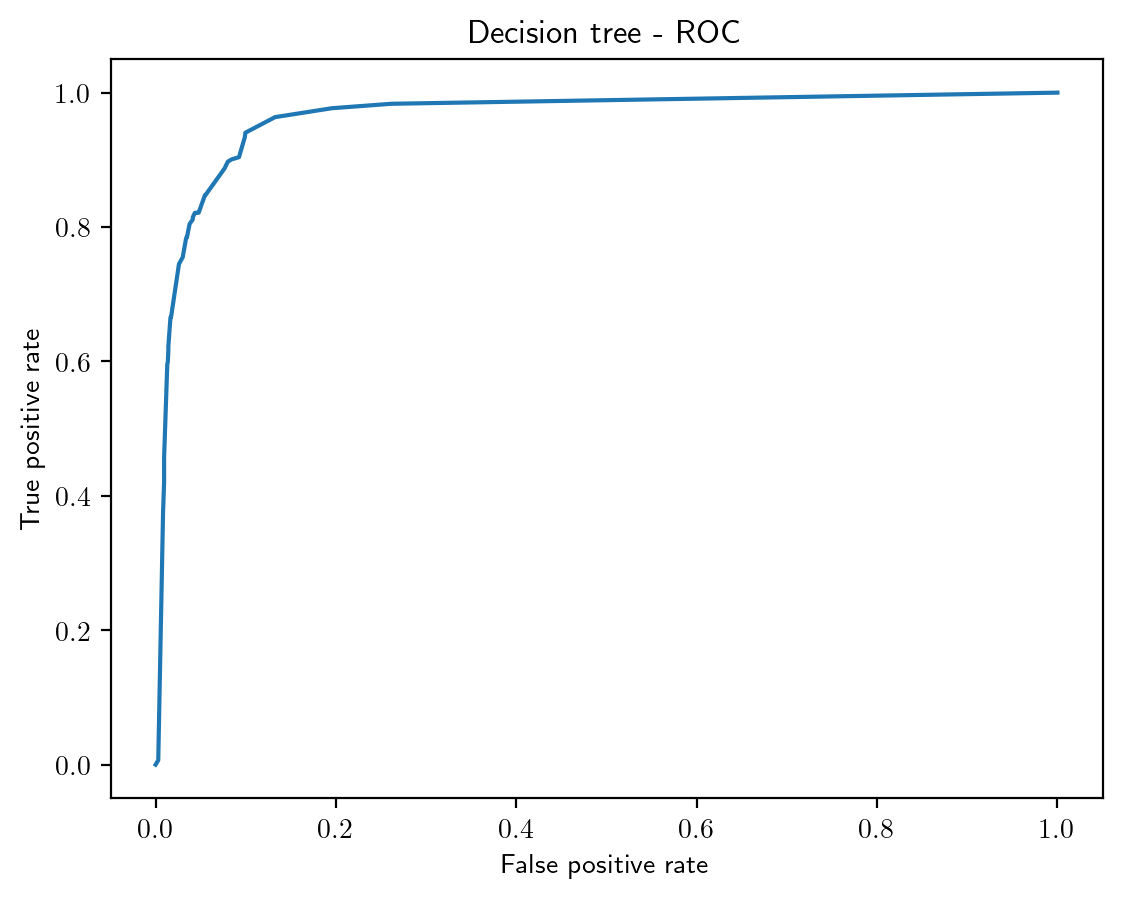

In [24]:
clf = DTC(max_depth=best_depth)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]
tree_rules = export_text(clf, feature_names=keys)
print(tree_rules)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title('Decision tree - ROC')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

CM = (confusion_matrix(y_test, y_pred))
print(f'AUC ROC {roc_auc_score(y_true=y_test, y_score=y_pred):.2f}')
print('confusion matrix')
print(CM)
tn, fp, fn, tp = CM.ravel()
completeness = (tp/(tp+fn))
contamination = (fp/(tp+fp))
print(f'completeness: {completeness:.2f}', f'contamination: {contamination:.2f}')

19


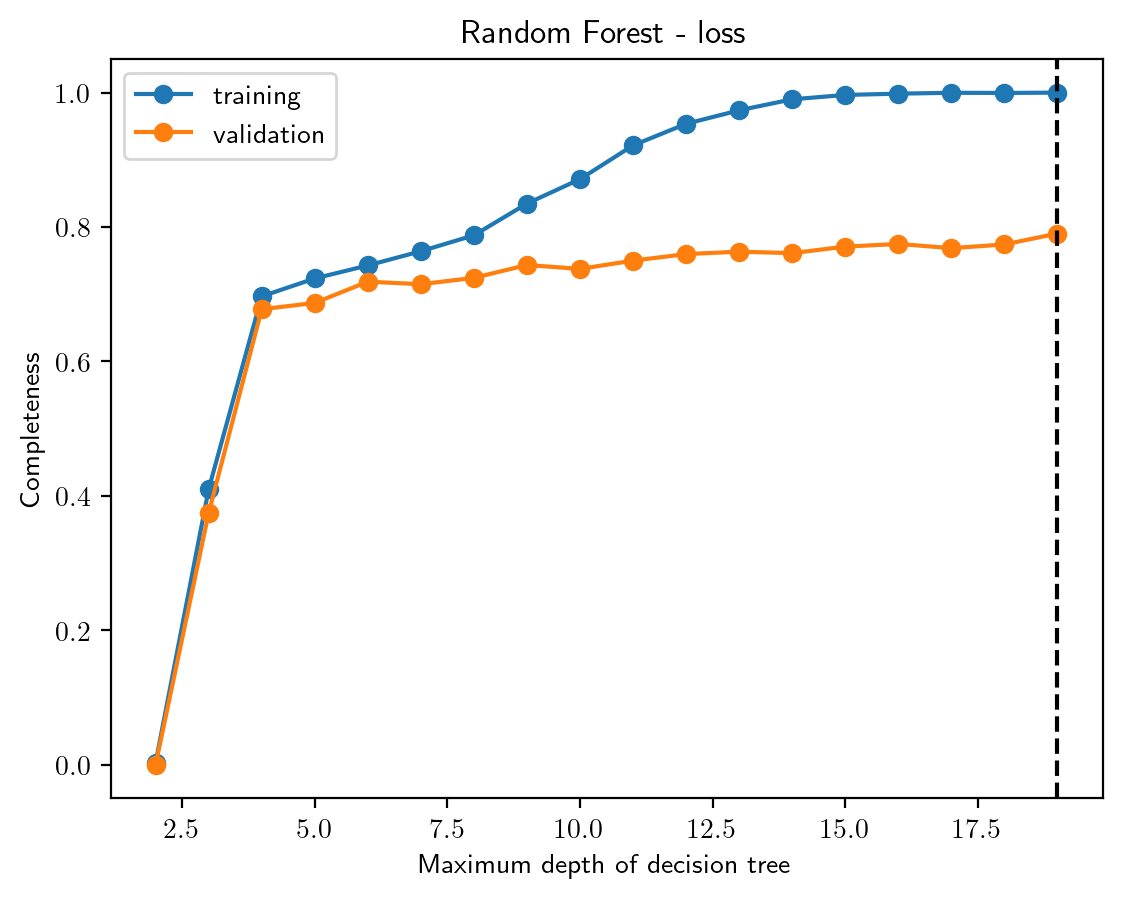

In [25]:
depths = np.arange(2,20)
tr_loss = np.zeros(len(depths))
cv_loss = np.zeros(len(depths))
for i,d in enumerate(depths):
        tr_loss[i], cv_loss[i] = kfold_cv(X_train, y_train, model = RFC(max_depth=d)) 

plt.plot(depths, tr_loss, label = 'training', marker = 'o')
plt.plot(depths, cv_loss, label = 'validation', marker = 'o')
plt.xlabel('Maximum depth of decision tree')
plt.ylabel('Completeness')
plt.legend()
plt.axvline(depths[np.argmax(cv_loss)], c = 'black', ls = '--')
plt.title('Random Forest - loss')
best_depth = depths[np.argmax(cv_loss)]
print(best_depth)

AUC ROC 0.88
confusion matrix
[[1663   35]
 [  64  238]]
completeness: 0.79 contamination: 0.13


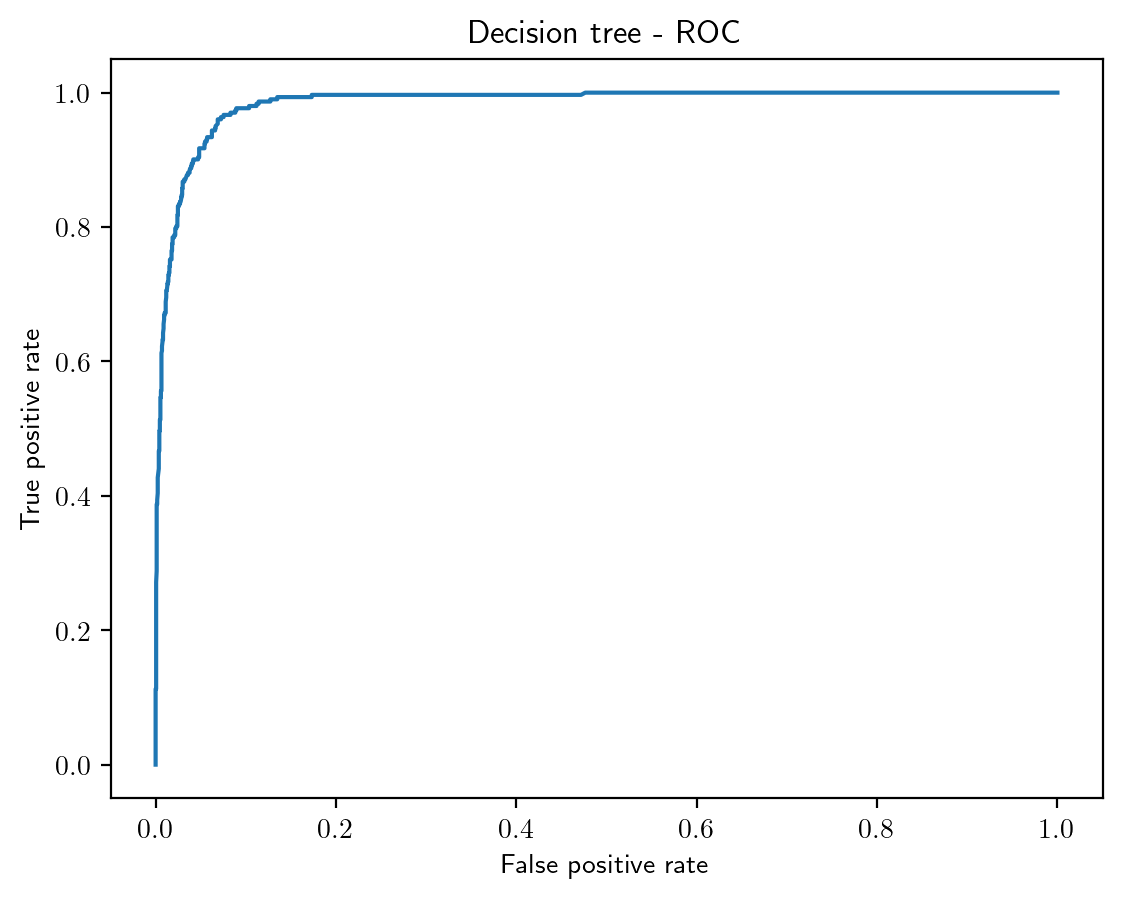

In [26]:
clf = RFC(max_depth=best_depth)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title('Decision tree - ROC')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

CM = (confusion_matrix(y_test, y_pred))
print(f'AUC ROC {roc_auc_score(y_true=y_test, y_score=y_pred):.2f}')
print('confusion matrix')
print(CM)
tn, fp, fn, tp = CM.ravel()
completeness = (tp/(tp+fn))
contamination = (fp/(tp+fp))
print(f'completeness: {completeness:.2f}', f'contamination: {contamination:.2f}')